# LASSO regression

In [2]:
import numpy as np
from sklearn.linear_model import Lasso

# Sample data
X = np.array([[1400, 3, 5],
              [1600, 3, 10],
              [1100, 2, 1],
              [2000, 4, 8]])

y = np.array([220000, 300000, 150000, 350000])

# Create a Lasso Regression model
lasso_model = Lasso(alpha=0.01)  # Adjust alpha for regularization strength. In lecture we used Lambda (noit alpha)
lasso_model.fit(X, y)

# Predict house price for a new property
new_property = np.array([[1800, 3, 6]])
predicted_price = lasso_model.predict(new_property)

print(f"Predicted price for the new property using Lasso Regression: ${predicted_price[0]:,.2f}")

Predicted price for the new property using Lasso Regression: $316,433.06


# Varaible selection using LASSO

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
import pandas as pd

#data
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

X.shape


(506, 13)

In [32]:
# Create a LassoCV model with cross-validation
ALPHA = np.logspace(0, 100, 20)
lasso_model = LassoCV(alphas= ALPHA, cv=5)
lasso_model.fit(X, y)

# Print selected features
selected_features = np.where(lasso_model.coef_ != 0)[0]
print(f"Selected Features: {selected_features}")

Selected Features: [ 0  1  5  6  7  8  9 10 11 12]


In [33]:
lasso_model.alpha_

1.0

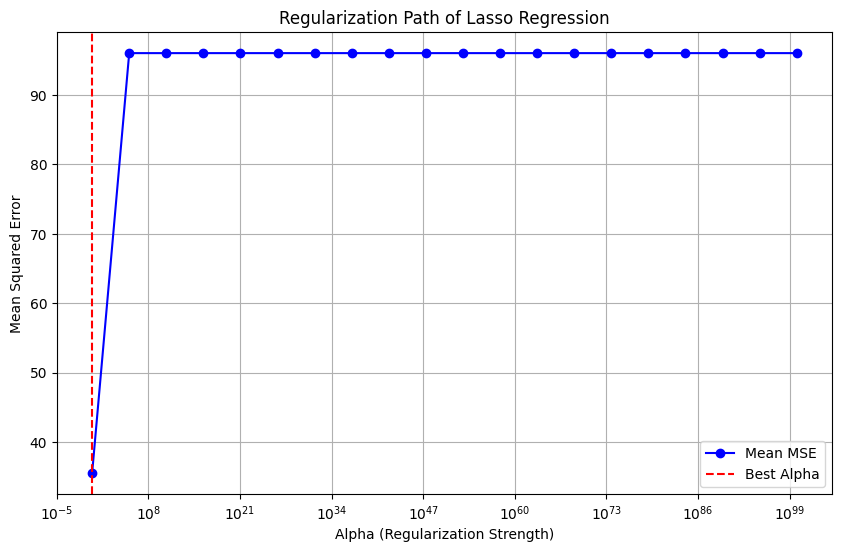

In [31]:
# Plot the regularization path
alphas = np.logspace(0, 100, 20)
plt.figure(figsize=(10, 6))
plt.plot(lasso_model.alphas_, np.mean(lasso_model.mse_path_, axis=1), '-o', color='b', label='Mean MSE')
plt.axvline(lasso_model.alpha_, color='r', linestyle='--', label='Best Alpha')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Regularization Path of Lasso Regression')
plt.legend()
plt.grid(True)
plt.show()